In [1]:
from fairchem.core.units.mlip_unit import load_predict_unit
from omegaconf import OmegaConf
import numpy as np
from ase.io import read, write
from ase.io.trajectory import Trajectory
from ase import units
from ase.md.langevin import Langevin
from ase.md.nptberendsen import NPTBerendsen  
from ase.constraints import ExpCellFilter       
from fairchem.core import FAIRChemCalculator


/home/moriya2524/.conda/envs/newtonnet/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-19 13:33:30,386	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
/home/moriya2524/.conda/envs/newtonnet/lib/python3.12/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a un

In [2]:
atoms = read("H2OBPc.xyz")

In [13]:

checkpoint_path = "/home/moriya2524/mlp/sources/UMA/UMA/checkpoints/uma-s-1p2.pt"
atom_refs = OmegaConf.load("/home/moriya2524/mlp/sources/UMA/UMA/references/iso_atom_elem_refs.yaml") 
predictor = load_predict_unit(
    path=checkpoint_path,
    inference_settings="default",
    device="cuda",
    atom_refs=atom_refs,
    form_elem_refs=None,
    workers=1,
)
calc = FAIRChemCalculator(predictor, task_name="omol")
atoms.calc = calc

In [18]:
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary, ZeroRotation

T = 100  
traj_file = f'H2OBPc_{T}K_NVT.traj'
log_file  = f'H2OBPc_{T}K_NVT.log'

MaxwellBoltzmannDistribution(atoms, temperature_K=T, rng=np.random.default_rng(42))
Stationary(atoms)    
ZeroRotation(atoms)  
dt = 1.0 * units.fs         
friction = 0.01 / units.fs  

dyn = Langevin(
    atoms,
    timestep=dt,
    temperature_K=T,
    friction=friction,
    rng=np.random.default_rng(42),
)


In [19]:
import time


traj = Trajectory(traj_file, 'w', atoms)
dyn.attach(traj.write, interval=1)
energies = []
temps    = []
t0       = time.time()

def log_step():
    step = dyn.nsteps
    e    = atoms.get_potential_energy()
    T_   = atoms.get_temperature()
    energies.append(e)
    temps.append(T_)
    elapsed = time.time() - t0
    print(f'Step {step:5d} | T = {T_:6.1f} K | E = {e:12.4f} eV | elapsed {elapsed:.1f}s')

dyn.attach(log_step, interval=10)
N_STEPS = 1000   # 1 fs × 1000 = 1 ps
dyn.run(N_STEPS)
traj.close()


Step     0 | T =   91.7 K | E =  -95996.1806 eV | elapsed 0.0s
Step    10 | T =  138.6 K | E =  -95996.9459 eV | elapsed 1.0s
Step    20 | T =  150.1 K | E =  -95997.3182 eV | elapsed 2.2s
Step    30 | T =  144.9 K | E =  -95997.3996 eV | elapsed 3.2s
Step    40 | T =  126.4 K | E =  -95997.3347 eV | elapsed 4.1s
Step    50 | T =  128.6 K | E =  -95997.4179 eV | elapsed 5.0s
Step    60 | T =  130.2 K | E =  -95997.4696 eV | elapsed 6.0s
Step    70 | T =  127.3 K | E =  -95997.4197 eV | elapsed 6.9s
Step    80 | T =  133.0 K | E =  -95997.5385 eV | elapsed 7.9s
Step    90 | T =  115.4 K | E =  -95997.3285 eV | elapsed 8.8s
Step   100 | T =  128.3 K | E =  -95997.7462 eV | elapsed 9.7s
Step   110 | T =  116.3 K | E =  -95997.6605 eV | elapsed 10.7s
Step   120 | T =  123.9 K | E =  -95997.8743 eV | elapsed 11.6s
Step   130 | T =  116.6 K | E =  -95997.8505 eV | elapsed 12.6s
Step   140 | T =  110.9 K | E =  -95997.6936 eV | elapsed 13.5s
Step   150 | T =  113.8 K | E =  -95997.8861 eV | e

In [20]:
from ase.io import read, write
traj = read(f'H2OBPc_{T}K_NVT.traj', index=':')
write(f'H2OBPc_{T}K.xyz', traj[500:1000])  # 多帧 xyz，VMD 可直接打开

/tmp/ipykernel_51758/3137446955.py:16: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_51758/3137446955.py:16: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_51758/3137446955.py:17: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  plt.savefig('H2OBPc_MD_monitor.png', dpi=150)
/tmp/ipykernel_51758/3137446955.py:17: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.savefig('H2OBPc_MD_monitor.png', dpi=150)


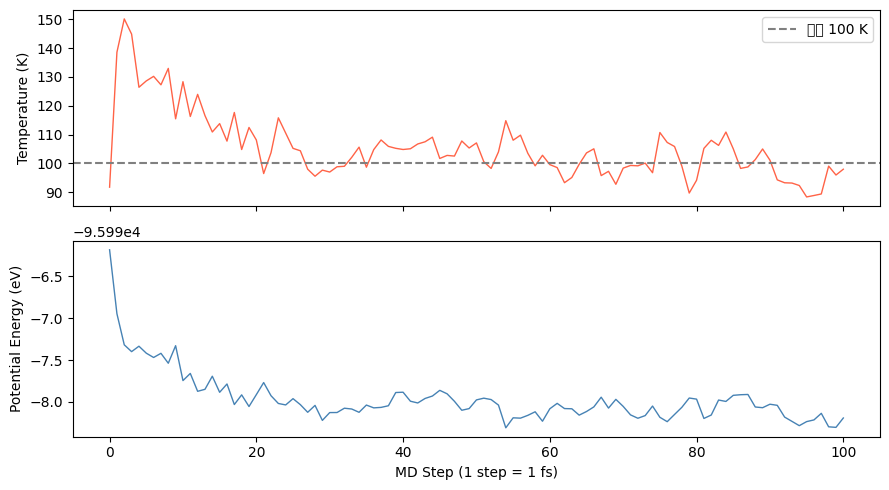

In [21]:

steps_logged = list(range(0, len(temps)))   # [0, 1, 2, ..., 1000]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True)

ax1.plot(steps_logged, temps, color='tomato', lw=1)
ax1.axhline(T, color='gray', ls='--', label=f'目标 {T} K')
ax1.set_ylabel('Temperature (K)')
ax1.legend()

ax2.plot(steps_logged, energies, color='steelblue', lw=1)
ax2.set_ylabel('Potential Energy (eV)')
ax2.set_xlabel('MD Step (1 step = 1 fs)')

plt.tight_layout()
plt.savefig('H2OBPc_MD_monitor.png', dpi=150)
plt.show()